In [1]:
from dataclasses import dataclass
import numpy as np
import os
import random
import torch
from torch import optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

if not os.path.exists("./KuiSCIMA"):
    !git clone https://github.com/SuziAI/KuiSCIMA.git
if not os.path.exists("./gui-tools"):
    !git clone https://github.com/SuziAI/gui-tools.git

from data_extraction import *
from image_manipulation import *
from model import *
from lvlvpu import *

from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib import cm

BATCH_SIZE = 100

total_dataset = open_lvlvpu_dataset("./TotalDataset/Music/")
total_dataset = get_cropped_dataset(total_dataset, remove_blobs=False)

In [2]:
## Normalizes the dataset to have mean 0 and standard deviation of 1
mean_list = torch.Tensor([torch.Tensor(entry["image"]).mean() for entry in total_dataset])/255
mean = mean_list.mean()
std = mean_list.std()

def normalize():
    return transforms.Normalize(mean=mean, std=std)
    
def get_validation_transforms(image_size=48):
    target_shrink = image_size - 8
    target_paste = image_size
    validation_transforms = transforms.Compose([
        transforms.ToTensor(),
        shrink(is_random=False, target_size=target_shrink),
        paste_to_square(is_random=False, target_size=target_paste),
        lambda img: transforms.functional.invert(img), # inverts image, needed for rotations
        normalize(), # normalize mean and variance
    ])
    return validation_transforms

display_transforms = transforms.Compose([
    transforms.ToTensor(),
    shrink(is_random=False, target_size=40),
    paste_to_square(is_random=False, target_size=45),
])

In [3]:
model = TemperatureScalingCalibrationModule(CnnModel(17))
model.load_state_dict(torch.load("./lvlv_model.std"))
model.eval()

TemperatureScalingCalibrationModule(
  (model): CnnModel(
    (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (fc1): Linear(in_features=4608, out_features=128, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
    (fc2): Linear(in_features=128, out_features=17, bias=True)
    (logits): LogSoftmax(dim=1)
  )
)

In [4]:
import umap
import pickle

def get_features(model, l):
    return model.model.get_representation(l)

def get_feature_dataset(dataset):
    class Dataset(torch.utils.data.Dataset):
        def __init__(self, return_pitch, dataset: list, model=None, tf=None):
            model.eval()
            concatenation = torch.cat([tf(entry["image"]).unsqueeze(0) for entry in dataset])
            
            self.X = get_features(model, concatenation)
            self.original = [entry["image"] for entry in dataset]
            self.y = [entry["annotation"] for entry in dataset]



            self.transform = tf

        def __len__(self):
            return len(self.X)

        def __getitem__(self, idx):
            sample = self.X[idx]
            label = self.y[idx]
            return sample, label
    
    um_ds = Dataset(return_pitch=True, dataset=dataset, model=model, tf=get_validation_transforms())
    return um_ds

/home/tristan/suziai_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
if not os.path.exists("lvlv_umap_models.pkl") or not os.path.exists("lvlv_umap_embeddings.pkl"):
    umap_dataset = get_feature_dataset(total_dataset)
    
    umap_lvlv = umap.UMAP(random_state=42).fit(umap_dataset.X.detach().numpy())
    
    with open("lvlv_umap_models.pkl", "ab") as file_handle:
        pickle.dump(umap_lvlv.transform, file_handle)
    
    umap_embedding = {
        "editions": [entry["edition"] for entry in total_dataset],
        "annotations": [entry["annotation"] for entry in total_dataset],
        "display_images": torch.cat([get_validation_transforms()(entry["image"]).unsqueeze(0) for entry in total_dataset]),
        "gui_images": torch.cat([display_transforms(entry["image"]).unsqueeze(0) for entry in total_dataset])*255,
        "embeddings": torch.Tensor(umap_lvlv.embedding_),
    }
    
    with open("lvlv_umap_embeddings.pkl", "ab") as file_handle:
        pickle.dump(umap_embedding, file_handle)

/home/tristan/suziai_env/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/home/tristan/suziai_env/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


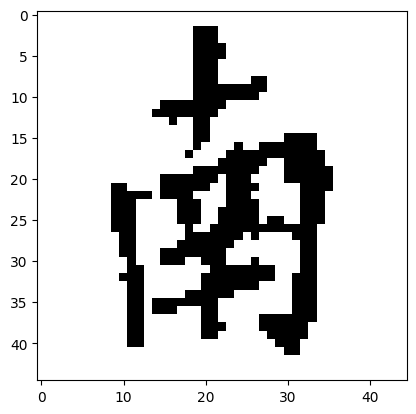

In [6]:
plt.imshow(display_transforms(total_dataset[0]["image"]).squeeze(), cmap="gray")

In [10]:
with open("lvlv_umap_models.pkl", "rb") as file_handle:
    umap_models = pickle.load(file_handle)
with open("lvlv_umap_embeddings.pkl", "rb") as file_handle:
    umap_embeddings = pickle.load(file_handle)

print(umap_embeddings.keys())

dict_keys(['editions', 'annotations', 'display_images', 'gui_images', 'embeddings'])


/tmp/ipykernel_5623/3263452390.py:4: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(umap_embeddings["embeddings"][:, 0], umap_embeddings["embeddings"][:, 1], s=5, c=[colors[label] for label in umap_embeddings["annotations"]], cmap='Spectral', alpha=0.8)


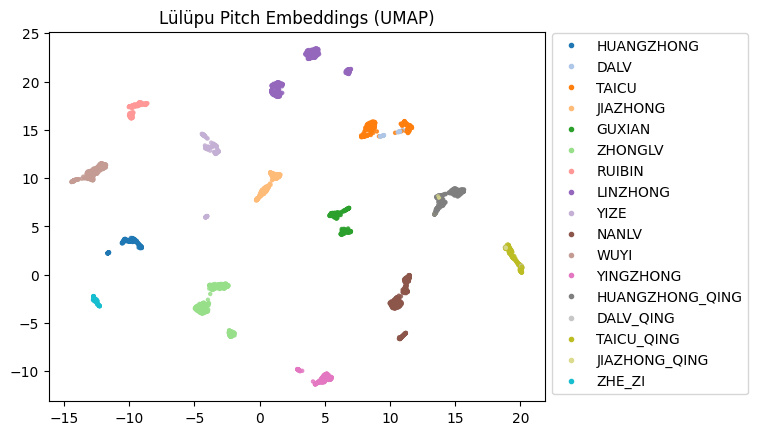

In [11]:

cmap = plt.get_cmap('tab20')
colors = [cmap(i / 17.0) for i in range(17)]
fig, ax = plt.subplots()
plt.scatter(umap_embeddings["embeddings"][:, 0], umap_embeddings["embeddings"][:, 1], s=5, c=[colors[label] for label in umap_embeddings["annotations"]], cmap='Spectral', alpha=0.8)
plt.title('Lülüpu Pitch Embeddings (UMAP)')
custom = [plt.Line2D([], [], marker='.', color=colors[label], linestyle='None') for label in range(17)]
plt.legend(handles = custom, labels=[ExtendedLvlv.from_class(label) for label in range(17)], bbox_to_anchor= (1.0, 0), loc= "lower left")

cmap = cm.gray

draw_indices = [2038, 1052, 2492, 2288, 1718, 2599, 276, 1417, 2067, 633, 2250, 1517, 1951, 2582, 675, 610, 19, 1533]
#for idx in draw_indices:
#    x, y, img = umap_embeddings["embeddings"][idx, 0], umap_embeddings["embeddings"][idx, 1], umap_embeddings["display_images"][idx]
#    img = cmap(img.squeeze())
#    im = OffsetImage(img, zoom=0.8*28/45)  # Adjust 'zoom' to control image size
#    ab = AnnotationBbox(im, (x, y), frameon=False)  # Place image at (x, y)
#    ax.add_artist(ab)
    
#plt.savefig(f"lvlv_umap_examples.pdf", format="pdf", bbox_inches="tight")
plt.savefig(f"lvlv_umap.pdf", format="pdf", bbox_inches="tight")
plt.show()

/tmp/ipykernel_5623/1196070281.py:4: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(umap_embeddings["embeddings"][:, 0], umap_embeddings["embeddings"][:, 1], s=5, c=[colors[label] for label in umap_embeddings["annotations"]], cmap='Spectral', alpha=0.8)


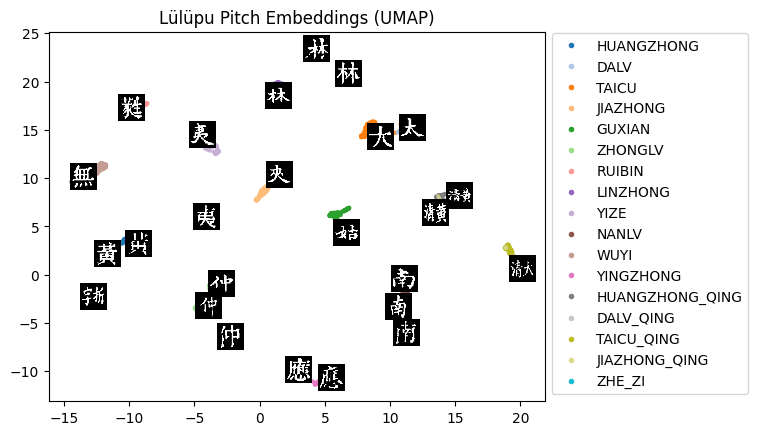

In [46]:

cmap = plt.get_cmap('tab20')
colors = [cmap(i / 17.0) for i in range(17)]
fig, ax = plt.subplots()
plt.scatter(umap_embeddings["embeddings"][:, 0], umap_embeddings["embeddings"][:, 1], s=5, c=[colors[label] for label in umap_embeddings["annotations"]], cmap='Spectral', alpha=0.8)
plt.title('Lülüpu Pitch Embeddings (UMAP)')
custom = [plt.Line2D([], [], marker='.', color=colors[label], linestyle='None') for label in range(17)]
plt.legend(handles = custom, labels=[ExtendedLvlv.from_class(label) for label in range(17)], bbox_to_anchor= (1.0, 0), loc= "lower left")
cmap = cm.gray

draw_indices = [
    2038, 1052, 2492, 2288,
    1718, 2599, 1417,
    2067, 633, 2250, 1517,
    1951, 2582, 675, 610,
    19, 1533, 2904, 2110,
    1638, 1020, 2358,
    1678, 2627, 1973,
]
for idx in draw_indices:
    x, y, img = umap_embeddings["embeddings"][idx, 0], umap_embeddings["embeddings"][idx, 1], umap_embeddings["display_images"][idx]
    img = cmap(img.squeeze())
    im = OffsetImage(img, zoom=0.4)  # Adjust 'zoom' to control image size
    ab = AnnotationBbox(im, (x, y), frameon=False)  # Place image at (x, y)
    ax.add_artist(ab)
    
plt.savefig(f"lvlv_umap_examples.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [44]:
# Get nearest neighbors

from sklearn.neighbors import NearestNeighbors

secondary_nbrs = NearestNeighbors(n_neighbors=3, algorithm='ball_tree').fit(umap_embeddings["embeddings"])
secondary_distances, secondary_indices = secondary_nbrs.kneighbors([[-3, 0]])
print(secondary_indices)

[[1973 3083 3052]]
